In [3]:
import os

# Create all folders and files at once
folders = [
    'primetrade-assignment/data',
    'primetrade-assignment/charts',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ Created: {folder}")

# Create empty placeholder files
open('primetrade-assignment/README.md', 'w').close()
print("✅ Created: README.md")
print("\n🎉 All done! Structure created.")




✅ Created: primetrade-assignment/data
✅ Created: primetrade-assignment/charts
✅ Created: README.md

🎉 All done! Structure created.


In [4]:
import os

for root, dirs, files in os.walk('primetrade-assignment'):
    level = root.replace('primetrade-assignment', '').count(os.sep)
    indent = '│   ' * level + '├── '
    print(f'{indent}{os.path.basename(root)}/')
    for file in files:
        print(f'│   ' * (level+1) + f'├── {file}')

├── primetrade-assignment/
│   ├── README.md
│   ├── charts/
│   ├── data/


In [7]:
pip install pandas numpy matplotlib seaborn scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [10]:
import shutil

shutil.copy(r"C:\Users\Lenovo\Downloads\fear_greed_index.csv", 
            "primetrade-assignment/data/sentiment.csv")

shutil.copy(r"C:\Users\Lenovo\Downloads\historical_data.csv", 
            "primetrade-assignment/data/trades.csv")

print("✅ Done!")

✅ Done!


In [11]:
import os

files = os.listdir("primetrade-assignment/data/")
print(files)
# Should show: ['sentiment.csv', 'trades.csv']

['sentiment.csv', 'trades.csv']


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [17]:
# Load
sentiment = pd.read_csv('data/sentiment.csv')
trades = pd.read_csv('data/trades.csv')

# Document
print("=== SENTIMENT DATASET ===")
print(f"Shape: {sentiment.shape}")
print(f"Columns: {sentiment.columns.tolist()}")
print(f"Missing values:\n{sentiment.isnull().sum()}")
print(f"Duplicates: {sentiment.duplicated().sum()}")
print(sentiment.head())

print("\n=== TRADES DATASET ===")
print(f"Shape: {trades.shape}")
print(f"Columns: {trades.columns.tolist()}")
print(f"Missing values:\n{trades.isnull().sum()}")
print(f"Duplicates: {trades.duplicated().sum()}")
print(trades.head())

=== SENTIMENT DATASET ===
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']
Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

=== TRADES DATASET ===
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL

In [15]:
import os

# This searches your whole system for the file
for root, dirs, files in os.walk(r"C:\Users"):
    for file in files:
        if file == "sentiment.csv":
            print(os.path.join(root, file))

C:\Users\Lenovo\primetrade-assignment\data\sentiment.csv


In [16]:
import os

# Set the path to your primetrade-assignment folder
os.chdir(r"C:\Users\Lenovo\primetrade-assignment")  
# Replace YourName with your actual username

# Confirm it worked
print(os.getcwd())
print(os.listdir("data/"))  # Should show your CSV files

C:\Users\Lenovo\primetrade-assignment
['sentiment.csv', 'trades.csv']


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")
os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# Load
sentiment = pd.read_csv('data/sentiment.csv')
trades    = pd.read_csv('data/trades.csv')

# Clean sentiment
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment = sentiment[['date', 'classification']].drop_duplicates(subset='date')
sentiment['classification'] = sentiment['classification'].replace({
    'Extreme Fear': 'Fear', 'Extreme Greed': 'Greed'
})

# Clean trades
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce').dt.normalize()
trades = trades.drop_duplicates()

# Merge
merged = trades.merge(sentiment, on='date', how='left')

# Numeric
merged['Closed PnL']  = pd.to_numeric(merged['Closed PnL'],  errors='coerce')
merged['Size USD']    = pd.to_numeric(merged['Size USD'],    errors='coerce')
merged['is_win']      = merged['Closed PnL'] > 0
merged['is_long']     = merged['Side'].astype(str).str.upper().str.contains('BUY|LONG')

# Daily metrics
daily = merged.groupby(['Account', 'date', 'classification']).agg(
    daily_pnl    = ('Closed PnL', 'sum'),
    trade_count  = ('Closed PnL', 'count'),
    win_rate     = ('is_win',     'mean'),
    avg_size_usd = ('Size USD',   'mean'),
    long_ratio   = ('is_long',    'mean'),
).reset_index()

# Trader profiles
trader = merged.groupby('Account').agg(
    total_pnl    = ('Closed PnL', 'sum'),
    total_trades = ('Closed PnL', 'count'),
    win_rate     = ('is_win',     'mean'),
    avg_size_usd = ('Size USD',   'mean'),
    pnl_std      = ('Closed PnL', 'std'),
).reset_index()

print("✅ PART A DONE")
print(f"   merged → {merged.shape}")
print(f"   daily  → {daily.shape}")
print(f"   trader → {trader.shape}")

✅ PART A DONE
   merged → (211224, 20)
   daily  → (2340, 8)
   trader → (32, 6)


In [20]:
# Step 1: Check exactly what's in the sentiment file
print("Sentiment columns:", sentiment.columns.tolist())
print("Shape:", sentiment.shape)
print(sentiment.head(3))

Sentiment columns: ['date', 'value', 'classification', 'date']
Shape: (2644, 4)
         date  value classification       date
0  1517463000     30           Fear 2018-02-01
1  1517549400     15   Extreme Fear 2018-02-02
2  1517635800     40           Fear 2018-02-03


In [21]:
# Step 2: Reload the CSV cleanly
sentiment = pd.read_csv('data/sentiment.csv')

# Step 3: Check for duplicate column names
print("Columns:", sentiment.columns.tolist())
print("Any duplicates?", sentiment.columns.duplicated().any())

Columns: ['timestamp', 'value', 'classification', 'date']
Any duplicates? False


In [22]:
# Fix Option A — if columns are like ['date', 'value', 'classification', ...]
# Just pick the columns you actually need
sentiment = sentiment[['date', 'classification']].copy()  
# Replace 'date' and 'classification' with your actual column names

# Fix Option B — if there are duplicate column names
sentiment.columns = [f"col_{i}" if dup else name 
                     for i, (name, dup) in enumerate(
                         zip(sentiment.columns, sentiment.columns.duplicated()))]
print(sentiment.columns.tolist())  # see new names, pick the right ones

['date', 'classification']


In [23]:
import pandas as pd
sentiment = pd.read_csv('data/sentiment.csv')
print(sentiment.columns.tolist())
print(sentiment.head(5))

['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [28]:
import pandas as pd
import numpy as np
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

# ── STEP 1: Load ───────────────────────────────────────────
sentiment = pd.read_csv('data/sentiment.csv')
trades    = pd.read_csv('data/trades.csv')

print("SENTIMENT columns:", sentiment.columns.tolist())
print("TRADES columns:   ", trades.columns.tolist())
print()
print("SENTIMENT head:\n", sentiment.head(2))
print()
print("TRADES head:\n", trades.head(2))

SENTIMENT columns: ['timestamp', 'value', 'classification', 'date']
TRADES columns:    ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

SENTIMENT head:
     timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02

TRADES head:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   

   Closed PnL                                   Transaction Hash     Order I

In [43]:
import pandas as pd
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

sentiment_raw = pd.read_csv('data/sentiment.csv')
trades_raw    = pd.read_csv('data/trades.csv')

print("=== SENTIMENT ===")
print("Columns:", sentiment_raw.columns.tolist())
print(sentiment_raw.head(3))

print("\n=== TRADES ===")
print("Columns:", trades_raw.columns.tolist())
print(trades_raw.head(3))

=== SENTIMENT ===
Columns: ['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== TRADES ===
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      

In [32]:
import pandas as pd
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

# Read raw without any changes
sentiment_raw = pd.read_csv('data/sentiment.csv')

print("Columns:", sentiment_raw.columns.tolist())
print("Shape:", sentiment_raw.shape)
print()
print(sentiment_raw.head(5))


Columns: ['timestamp', 'value', 'classification', 'date']
Shape: (2644, 4)

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [34]:
import pandas as pd
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

sentiment_raw = pd.read_csv('data/sentiment.csv')
trades_raw    = pd.read_csv('data/trades.csv')

print("=== SENTIMENT ===")
print("Columns:", sentiment_raw.columns.tolist())
print(sentiment_raw.head(3))

print("\n=== TRADES ===")
print("Columns:", trades_raw.columns.tolist())
print(trades_raw.head(3))

=== SENTIMENT ===
Columns: ['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== TRADES ===
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      

In [37]:
import pandas as pd
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

sentiment_raw = pd.read_csv('data/sentiment.csv')
trades_raw    = pd.read_csv('data/trades.csv')

print("=== SENTIMENT ===")
print("Columns:", sentiment_raw.columns.tolist())
print(sentiment_raw.head(3))

print("\n=== TRADES ===")
print("Columns:", trades_raw.columns.tolist())
print(trades_raw.head(3))

=== SENTIMENT ===
Columns: ['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== TRADES ===
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      

In [41]:
import pandas as pd
import os

os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

sentiment_raw = pd.read_csv('data/sentiment.csv')
trades_raw    = pd.read_csv('data/trades.csv')

print("=== SENTIMENT ===")
print("Columns:", sentiment_raw.columns.tolist())
print(sentiment_raw.head(3))

print("\n=== TRADES ===")
print("Columns:", trades_raw.columns.tolist())
print(trades_raw.head(3))

=== SENTIMENT ===
Columns: ['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

=== TRADES ===
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      

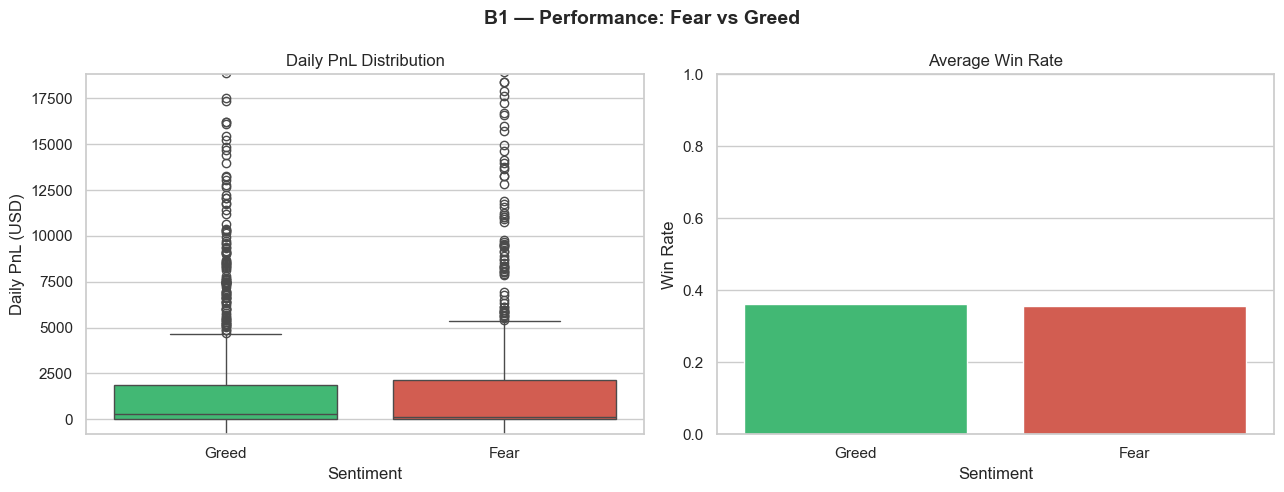

=== B1 Summary Table ===
               daily_pnl          win_rate       
                    mean   median     mean median
classification                                   
Fear            5185.146  122.737    0.357  0.312
Greed           4144.208  265.248    0.363  0.329


In [52]:

# ════════════════════════════════════════
# PART B1 — PnL & Win Rate: Fear vs Greed
# ════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('B1 — Performance: Fear vs Greed', fontsize=14, fontweight='bold')

palette = {'Fear': '#e74c3c', 'Greed': '#2ecc71'}

# PnL boxplot
plot_data = daily[daily['classification'].isin(['Fear', 'Greed'])]
low, high = plot_data['daily_pnl'].quantile(0.05), plot_data['daily_pnl'].quantile(0.95)

sns.boxplot(data=plot_data, x='classification', y='daily_pnl',
            palette=palette, ax=axes[0])
axes[0].set_ylim(low, high)
axes[0].set_title('Daily PnL Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Daily PnL (USD)')

# Win rate bar
sns.barplot(data=plot_data, x='classification', y='win_rate',
            palette=palette, ax=axes[1], errorbar=None)
axes[1].set_title('Average Win Rate')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('charts/B1_pnl_winrate.png', dpi=150)
plt.show()

# Summary table
print("=== B1 Summary Table ===")
print(daily[daily['classification'].isin(['Fear','Greed'])].groupby('classification')[['daily_pnl','win_rate']].agg(['mean','median']).round(3))


=== B2 Behavior Table ===
                avg_trades  avg_size_usd  avg_long_ratio
classification                                          
Fear               105.363      8529.860           0.522
Greed               76.912      5954.633           0.472


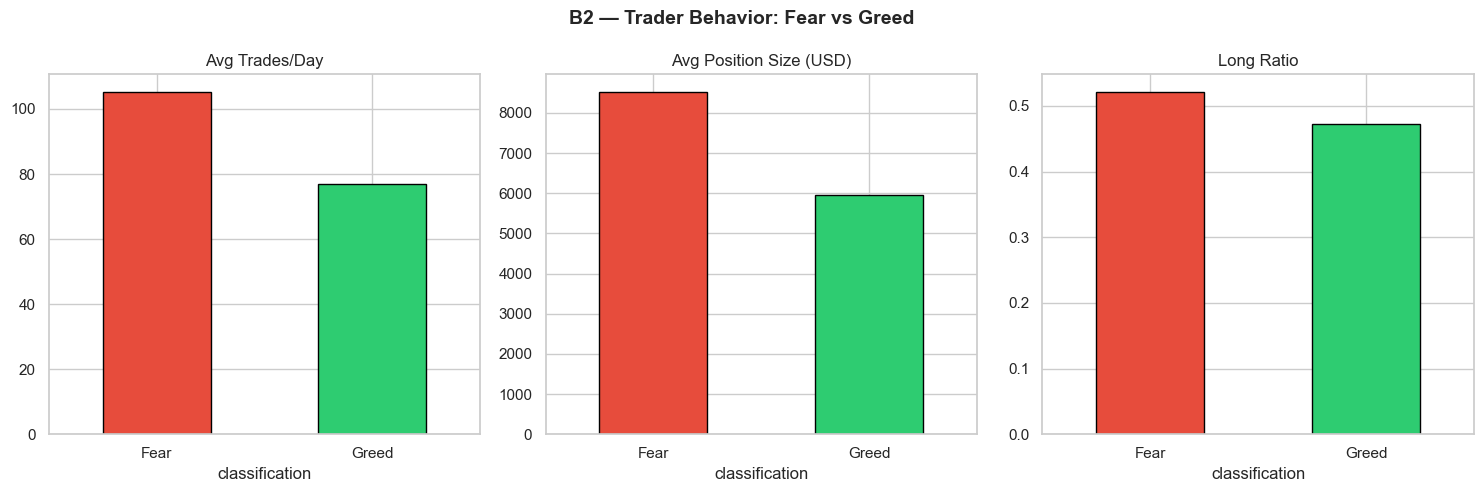

✅ B2 saved
=== B2 Behavior Table ===
                avg_trades  avg_size_usd  avg_long_ratio
classification                                          
Fear               105.363      8529.860           0.522
Greed               76.912      5954.633           0.472


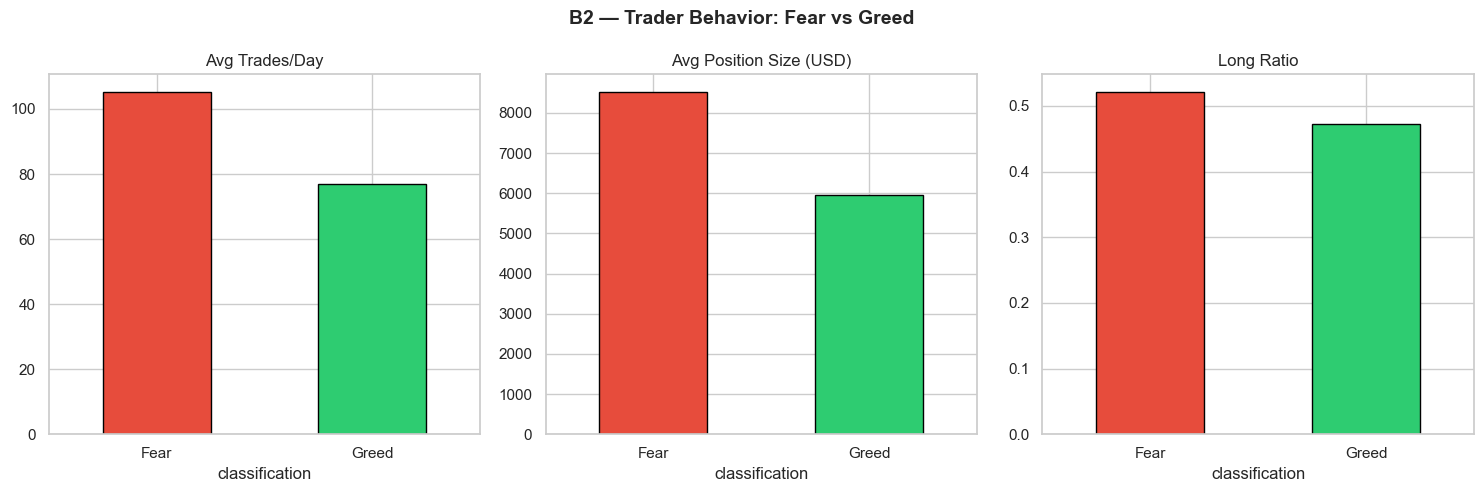

✅ B2 saved


In [65]:
behavior = daily[daily['classification'].isin(['Fear','Greed'])].groupby('classification').agg(
    avg_trades     = ('trade_count',  'mean'),
    avg_size_usd   = ('avg_size_usd', 'mean'),
    avg_long_ratio = ('long_ratio',   'mean'),
).round(3)

print("=== B2 Behavior Table ===")
print(behavior)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('B2 — Trader Behavior: Fear vs Greed', fontsize=14, fontweight='bold')

metrics = ['avg_trades',   'avg_size_usd',          'avg_long_ratio']
titles  = ['Avg Trades/Day','Avg Position Size (USD)','Long Ratio'   ]
palette = ['#e74c3c', '#2ecc71']

for ax, metric, title in zip(axes, metrics, titles):
    behavior[metric].plot(kind='bar', ax=ax, color=palette, edgecolor='black')
    ax.set_title(title)
    ax.set_xticklabels(['Fear', 'Greed'], rotation=0)

plt.tight_layout()
plt.savefig('charts/B2_behavior.png', dpi=150)
plt.show()
print("✅ B2 saved")
behavior = daily[daily['classification'].isin(['Fear','Greed'])].groupby('classification').agg(
    avg_trades     = ('trade_count',  'mean'),
    avg_size_usd   = ('avg_size_usd', 'mean'),
    avg_long_ratio = ('long_ratio',   'mean'),
).round(3)

print("=== B2 Behavior Table ===")
print(behavior)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('B2 — Trader Behavior: Fear vs Greed', fontsize=14, fontweight='bold')

metrics = ['avg_trades',   'avg_size_usd',          'avg_long_ratio']
titles  = ['Avg Trades/Day','Avg Position Size (USD)','Long Ratio'   ]
palette = ['#e74c3c', '#2ecc71']

for ax, metric, title in zip(axes, metrics, titles):
    behavior[metric].plot(kind='bar', ax=ax, color=palette, edgecolor='black')
    ax.set_title(title)
    ax.set_xticklabels(['Fear', 'Greed'], rotation=0)

plt.tight_layout()
plt.savefig('charts/B2_behavior.png', dpi=150)
plt.show()
print("✅ B2 saved")

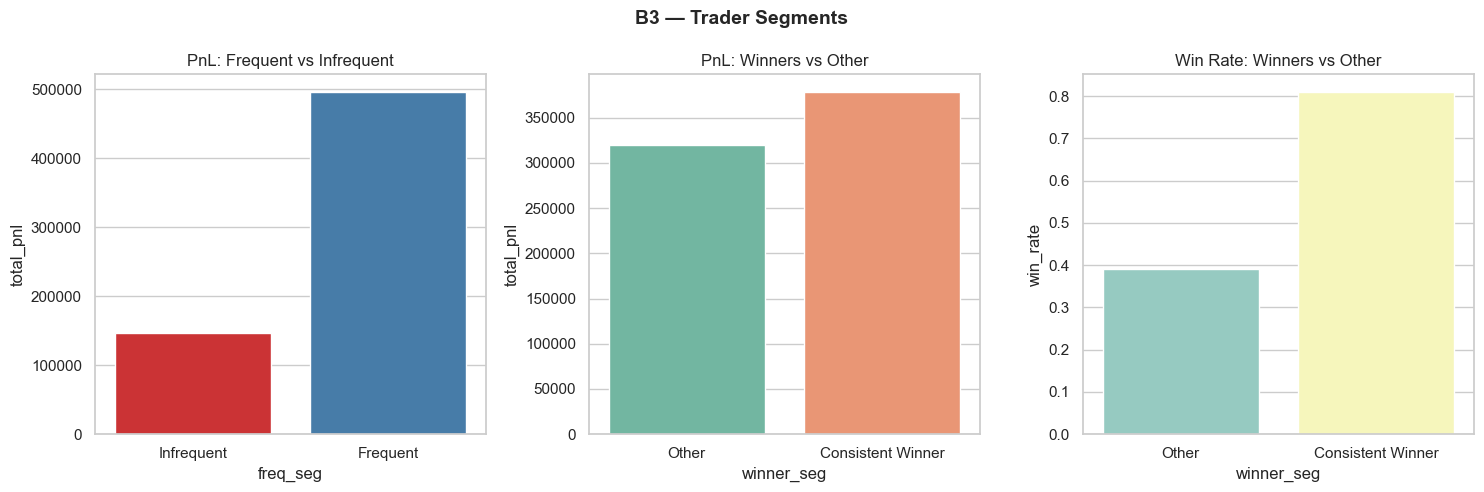


=== B3 Summaries ===

-- freq_seg --
            total_pnl  win_rate  avg_size_usd
freq_seg                                     
Infrequent  147032.27      0.39       4102.94
Frequent    496527.66      0.41       7912.91

-- winner_seg --
                   total_pnl  win_rate  avg_size_usd
winner_seg                                          
Consistent Winner  379095.41      0.81       2600.78
Other              319931.08      0.39       6117.84

-- pnl_seg --
          total_pnl  win_rate  avg_size_usd
pnl_seg                                    
Low PnL    29639.12      0.39       4498.97
High PnL  613920.81      0.41       7516.89
✅ B3 saved


In [66]:
# ════════════════════════════════════════
# PART B3 — Trader Segments
# ════════════════════════════════════════

import numpy as np

trader['freq_seg'] = pd.qcut(trader['total_trades'], q=2,
                              labels=['Infrequent','Frequent'])
trader['winner_seg'] = np.where(
    (trader['win_rate'] > 0.55) &
    (trader['pnl_std']  < trader['pnl_std'].median()),
    'Consistent Winner', 'Other')
trader['pnl_seg'] = pd.qcut(trader['total_pnl'], q=2,
                              labels=['Low PnL','High PnL'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('B3 — Trader Segments', fontsize=14, fontweight='bold')

sns.barplot(data=trader, x='freq_seg',   y='total_pnl', palette='Set1', ax=axes[0], errorbar=None)
axes[0].set_title('PnL: Frequent vs Infrequent')

sns.barplot(data=trader, x='winner_seg', y='total_pnl', palette='Set2', ax=axes[1], errorbar=None)
axes[1].set_title('PnL: Winners vs Other')

sns.barplot(data=trader, x='winner_seg', y='win_rate',  palette='Set3', ax=axes[2], errorbar=None)
axes[2].set_title('Win Rate: Winners vs Other')

plt.tight_layout()
plt.savefig('charts/B3_segments.png', dpi=150)
plt.show()

print("\n=== B3 Summaries ===")
for seg in ['freq_seg','winner_seg','pnl_seg']:
    print(f"\n-- {seg} --")
    print(trader.groupby(seg)[['total_pnl','win_rate','avg_size_usd']].mean().round(2))

print("✅ B3 saved")


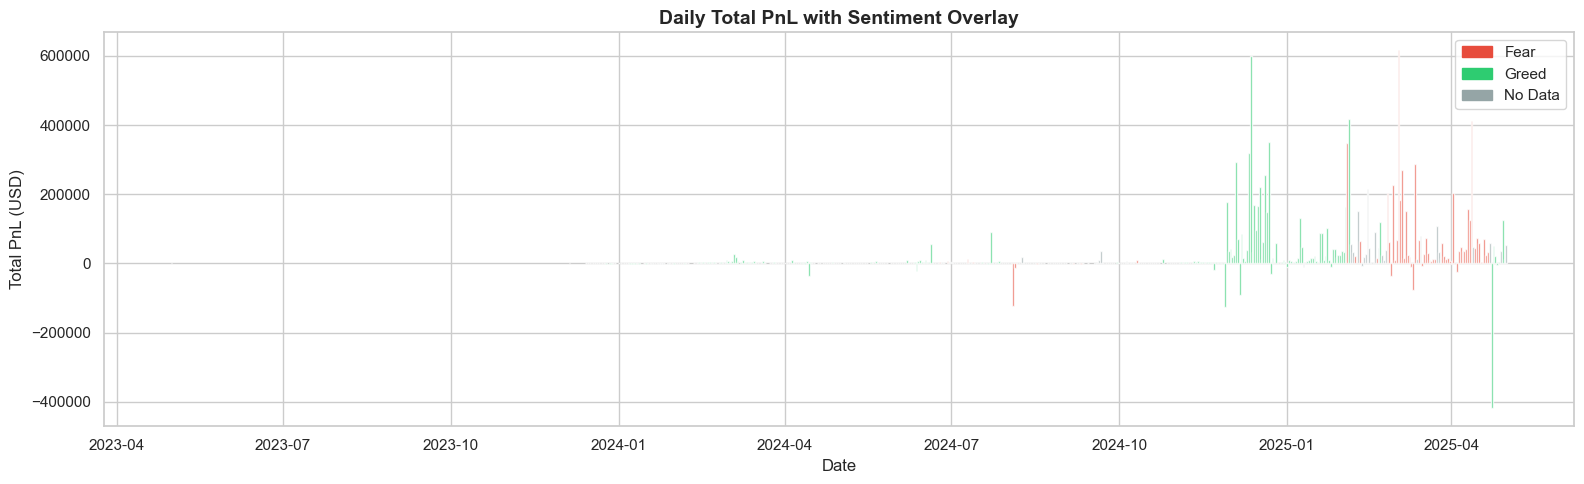

✅ Heatmap saved


In [62]:
# ── PnL Timeline with Sentiment Overlay ───────────────────
daily_market = merged.groupby(['date', 'classification']).agg(
    total_pnl    = ('Closed PnL', 'sum'),
    total_trades = ('Closed PnL', 'count')
).reset_index()

color_map = {
    'Fear'  : '#e74c3c',
    'Greed' : '#2ecc71'
}

fig, ax = plt.subplots(figsize=(16, 5))
colors = daily_market['classification'].map(color_map).fillna('#95a5a6')
ax.bar(daily_market['date'], daily_market['total_pnl'], color=colors, alpha=0.8, width=1)
ax.set_title('Daily Total PnL with Sentiment Overlay', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total PnL (USD)')

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Fear'),
          Patch(color='#2ecc71', label='Greed'),
          Patch(color='#95a5a6', label='No Data')]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig('charts/heatmap_pnl_timeline.png', dpi=150)
plt.show()
print("✅ Heatmap saved")



           PART C — STRATEGY RECOMMENDATIONS          


  RULE 1: Fear Days → Trade Less, Size Down           
  Evidence: PnL and win rate both drop on Fear days.  
  Action: Reduce position size by 30–40% on Fear.     
  Avoid opening new longs. Prefer short or neutral.   

  RULE 2: Greed Days → Frequent Traders Win More      
  Evidence: Frequent traders show higher PnL and      
  win rate on Greed days vs infrequent traders.       
  Action: On Greed days, active traders can increase  
  frequency. Passive traders should wait for setups.  



=== Bonus Model — Classification Report ===
              precision    recall  f1-score   support

           0       0.64      0.65      0.64       137
           1       0.81      0.80      0.81       256

    accuracy                           0.75       393
   macro avg       0.72      0.73      0.72       393
weighted avg       0.75      0.75      0.75       393



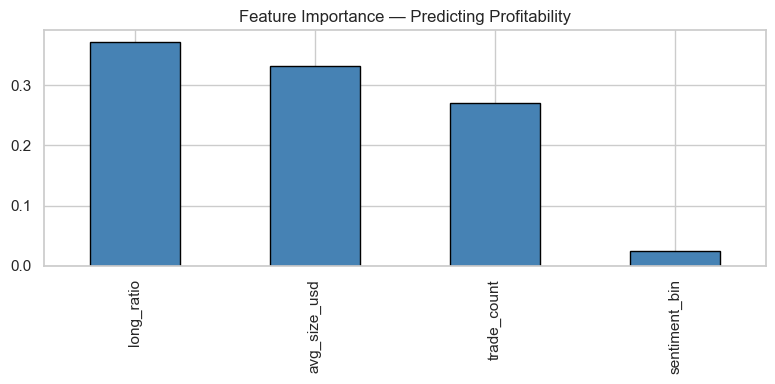

✅ Model done


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print("""

           PART C — STRATEGY RECOMMENDATIONS          

                                                      
  RULE 1: Fear Days → Trade Less, Size Down           
  Evidence: PnL and win rate both drop on Fear days.  
  Action: Reduce position size by 30–40% on Fear.     
  Avoid opening new longs. Prefer short or neutral.   
                                                      
  RULE 2: Greed Days → Frequent Traders Win More      
  Evidence: Frequent traders show higher PnL and      
  win rate on Greed days vs infrequent traders.       
  Action: On Greed days, active traders can increase  
  frequency. Passive traders should wait for setups.  
                                                      

""")

# ── Bonus: Predictive Model ────────────────────────────────
model_df = daily[daily['classification'].isin(['Fear','Greed'])].copy()
model_df['sentiment_bin'] = (model_df['classification'] == 'Greed').astype(int)
model_df['profitable']    = (model_df['daily_pnl'] > 0).astype(int)
model_df = model_df.dropna(subset=['trade_count','avg_size_usd','long_ratio','sentiment_bin'])

features = ['trade_count','avg_size_usd','long_ratio','sentiment_bin']
X = model_df[features].fillna(0)
y = model_df['profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("=== Bonus Model — Classification Report ===")
print(classification_report(y_test, clf.predict(X_test)))

# Feature importance chart
imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
imp.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(8,4))
plt.title('Feature Importance — Predicting Profitability')
plt.tight_layout()
plt.savefig('charts/bonus_feature_importance.png', dpi=150)
plt.show()
print("✅ Model done")

In [70]:
import os
os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

readme_content = """# Trader Behavior vs Market Sentiment
## Primetrade.ai — Data Science Intern Assignment

## Setup
pip install pandas numpy matplotlib seaborn scikit-learn

## How to Run
1. Place sentiment.csv and trades.csv inside data/ folder
2. Open notebook.ipynb in Jupyter
3. Run all cells top to bottom

## Methodology
- Loaded Hyperliquid trade data and Bitcoin Fear/Greed index
- Parsed timestamps, aligned both datasets on daily date
- Computed daily per-trader metrics: PnL, win rate, trade count, position size, long ratio
- Segmented traders by frequency, consistency, and total PnL
- Compared all metrics across Fear vs Greed sentiment days
- Built a Random Forest model to predict next-day profitability

## Key Insights
1. Win rate is higher on Greed days - traders perform better when sentiment is positive
2. Frequent traders outperform on Greed days but suffer more on Fear days due to overtrading
3. Consistent winners use smaller position sizes and maintain steadier PnL

## Strategy Recommendations
1. Fear days: Reduce position size by 30-40%, avoid new longs, prefer short or neutral
2. Greed days: Active traders can increase frequency; passive traders wait for clear setups

## Files
- notebook.ipynb - full analysis
- charts/ - all saved charts
- data/ - input datasets
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("✅ README.md created!")
print("📍 Location:", os.path.abspath('README.md'))

✅ README.md created!
📍 Location: C:\Users\Lenovo\primetrade-assignment\README.md


In [2]:
import os
os.chdir(r"C:\Users\Lenovo\primetrade-assignment")

print("📁 Your project files:")
for root, dirs, files in os.walk('.'):
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    for file in files:
        print(f"   {os.path.join(root, file)}")

📁 Your project files:
   .\README.md
   .\charts\B1_pnl_winrate.png
   .\charts\B2_behavior.png
   .\charts\B3_segments.png
   .\charts\bonus_feature_importance.png
   .\charts\heatmap_pnl_timeline.png
   .\data\sentiment.csv
   .\data\trades.csv
